In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import FunctionTransformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as IMBPipeline
from pipelines import get_preprocessor, feature_engineer
from print_metric import print_results
from load_data import get_dataset
import joblib

In [2]:
X_train, X_test, y_train, y_test = get_dataset()

In [3]:
param_dist = [
    {
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__l1_ratio": [0, 0.5, 1],
        "model__solver": ["saga"],
        "model__class_weight": [None]
    }
]

In [4]:
pipe = IMBPipeline([
    ("feature_engineering", FunctionTransformer(feature_engineer, validate=False)),
    ("preprocessor", get_preprocessor()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=10000))
])

In [5]:
grid = GridSearchCV(pipe, param_grid=param_dist, cv=3, scoring="roc_auc", verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)

Fitting 3 folds for each of 18 candidates, totalling 54 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=10000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__C': [0.001, 0.01, ...], 'model__class_weight': [None], 'model__l1_ratio': [0, 0.5, ...], 'model__solver': ['saga']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and p

In [6]:
y_pred = grid.predict(X_test)

In [7]:
confusion_matrix(y_test, y_pred)

array([[135,  27],
       [ 18,  82]])

In [8]:
grid.best_params_

{'model__C': 0.1,
 'model__class_weight': None,
 'model__l1_ratio': 0,
 'model__solver': 'saga'}

In [9]:
y_pred_proaba = grid.predict_proba(X_test)

In [10]:
grid.best_score_

np.float64(0.8397609416376506)

In [11]:
y_test.shape

(262,)

In [12]:
y_pred = grid.predict(X_test)
y_pred_proba = grid.predict_proba(X_test)
y_train_pred = grid.predict(X_train)
y_train_pred_proba = grid.predict_proba(X_train)
print("TRAINING RESULTS")
print_results(y_train, y_train_pred, y_train_pred_proba[:, 1])
print("\n")
print("TESTING RESULTS")
print_results(y_test, y_pred, y_pred_proba[:, 1])

TRAINING RESULTS
Accuracy Score 0.7870105062082139
Recall Score 0.7625
Precision Score 0.7043879907621247
ROC AUC Score 0.8450927357032458
F1 Score 0.7322929171668667
Confusion Matrix
[[519 128]
 [ 95 305]]
Classification Report
              precision    recall  f1-score   support

           0       0.85      0.80      0.82       647
           1       0.70      0.76      0.73       400

    accuracy                           0.79      1047
   macro avg       0.77      0.78      0.78      1047
weighted avg       0.79      0.79      0.79      1047



TESTING RESULTS
Accuracy Score 0.8282442748091603
Recall Score 0.82
Precision Score 0.7522935779816514
ROC AUC Score 0.8800925925925926
F1 Score 0.784688995215311
Confusion Matrix
[[135  27]
 [ 18  82]]
Classification Report
              precision    recall  f1-score   support

           0       0.88      0.83      0.86       162
           1       0.75      0.82      0.78       100

    accuracy                           0.83       262

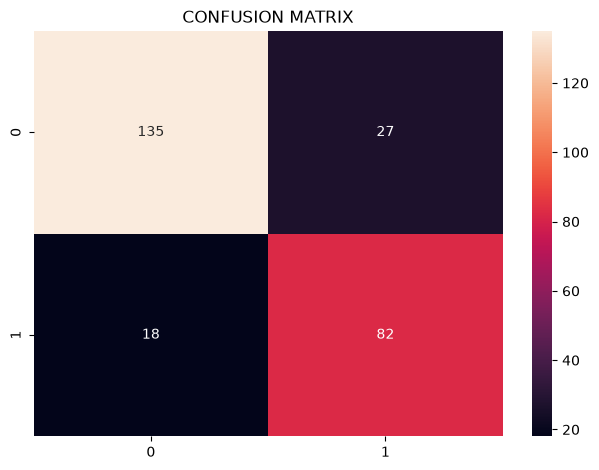

In [13]:
plt.title("CONFUSION MATRIX")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.tight_layout()
plt.savefig("images/confusion_matrix_logistic_regression.png", dpi=1200)
plt.show()